# <span style="color:#1a6b3c; font-size:32px">⚽ Final Project — Group 9</span>

<font size="5">

**By: Chad Himes (2774762), Aarin Singh (2758062), Sammy Paradise (2737621)**

</font>

---


## Introduction

Soccer (known as football outside the United States) is the world's most popular sport, with billions of fans across every continent. Unlike sports that are dominant in one region, soccer is genuinely global — yet the top players in the game tend to cluster around a surprisingly small number of countries. Understanding *which* countries produce the best players, and *why*, is a question that intersects culture, infrastructure, coaching tradition, and athletic genetics. To explore it, we use data from the FIFA video game series (FIFA 21 and FIFA 22), which assigns numeric ratings to thousands of real-world professional players across attributes like pace, shooting, passing, dribbling, defending, and physicality. Although these are video game statistics, they are researched and updated by a large team of scouts and analysts at EA Sports, making them a widely accepted proxy for real-world player quality.

Our analysis asks: **Which countries produce the best soccer players, and does the answer differ between men and women?** We compare the top nations by average overall player rating and then drill into individual skill attributes — pace, shooting, passing, dribbling, defending, and physicality — to see whether certain countries specialize in particular playing styles. We also examine whether these rankings are stable across the two most recent FIFA editions (21 and 22). Our findings show that Brazil and France consistently top the men's rankings, while the United States and Germany lead for women, and that meaningful skill-based differences exist across nationalities beyond a single summary rating.


## Data Description

We use four CSV files drawn from the [FIFA Players dataset on Kaggle](https://www.kaggle.com/datasets/joebeachcapital/fifa-players): `players_21.csv`, `players_22.csv`, `female_players_21.csv`, and `female_players_22.csv`. Each row represents one player as rated in that edition of the FIFA video game. The male datasets contain roughly 18,900 and 19,200 players respectively; the female datasets contain approximately 345 and 391 players. Each table shares the same 110 columns, covering identifiers (name, nationality, club), physical attributes (age, height, weight), contract information, and a rich set of numeric skill ratings — overall, potential, pace, shooting, passing, dribbling, defending, and physicality, as well as detailed sub-attributes (e.g., `movement_sprint_speed`, `power_strength`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# ── Load raw data ──────────────────────────────────────────────────────────
m21 = pd.read_csv('players_21.csv')
m22 = pd.read_csv('players_22.csv')
f21 = pd.read_csv('female_players_21.csv')
f22 = pd.read_csv('female_players_22.csv')

print(f"Male   FIFA 21: {m21.shape[0]:,} players, {m21.shape[1]} columns")
print(f"Male   FIFA 22: {m22.shape[0]:,} players, {m22.shape[1]} columns")
print(f"Female FIFA 21: {f21.shape[0]:,} players, {f21.shape[1]} columns")
print(f"Female FIFA 22: {f22.shape[0]:,} players, {f22.shape[1]} columns")


Male   FIFA 21: 18,944 players, 110 columns
Male   FIFA 22: 19,239 players, 110 columns
Female FIFA 21: 345 players, 110 columns
Female FIFA 22: 391 players, 110 columns


### Merging

We combine the four tables in two stages. First we tag each dataframe with `gender` (`'Male'` / `'Female'`) and `fifa_year` (`21` / `22`) columns, then concatenate all four into a single unified dataframe. Because all four files share identical column names, no column renaming is needed. Using a single merged table lets us run the same analysis code across gender and year combinations without duplicating logic.


In [2]:
# ── Tag and merge ──────────────────────────────────────────────────────────
def tag(df, gender, year):
    df = df.copy()
    df['gender']    = gender
    df['fifa_year'] = year
    return df

all_players = pd.concat([
    tag(m21, 'Male',   21),
    tag(m22, 'Male',   22),
    tag(f21, 'Female', 21),
    tag(f22, 'Female', 22),
], ignore_index=True)

print(f"Merged dataset: {all_players.shape[0]:,} rows × {all_players.shape[1]} columns")
all_players[['short_name','nationality_name','overall','pace','shooting',
             'passing','dribbling','defending','physic','gender','fifa_year']].head(4)


Merged dataset: 38,919 rows × 112 columns


,short_name,nationality_name,overall,pace,shooting,passing,dribbling,defending,physic,gender,fifa_year
0,L. Messi,Argentina,93,85.0,92.0,91.0,95.0,38.0,65.0,Male,21
1,Cristiano Ronaldo,Portugal,92,89.0,93.0,81.0,89.0,35.0,77.0,Male,21
2,R. Lewandowski,Poland,91,78.0,91.0,78.0,85.0,43.0,82.0,Male,21
3,Neymar Jr,Brazil,91,91.0,85.0,86.0,94.0,36.0,59.0,Male,21


### Data Cleaning

The six main skill attributes (`pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic`) are stored as strings in the raw files for some rows (they contain `+`/`-` modifiers for the position-rating cells, e.g. `"72+3"`). We extract just the numeric base value with a regex, then cast to a nullable integer type. We also drop the small number of rows where `nationality_name` is missing and restrict to outfield players (overall rating > 40) to exclude placeholder or retired goalkeeper entries with zeroed-out field stats. After cleaning, no nulls remain in the columns we analyze.


In [3]:
# ── Clean skill columns ───────────────────────────────────────────────────
skill_cols = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

def clean_skill(series):
    """Extract the leading integer from strings like '72+3' or '72'."""
    return pd.to_numeric(
        series.astype(str).str.extract(r'^(\d+)', expand=False),
        errors='coerce'
    )

for col in skill_cols:
    all_players[col] = clean_skill(all_players[col])

# Drop missing nationality and very low-rated rows
all_players = all_players.dropna(subset=['nationality_name'])
all_players = all_players[all_players['overall'] > 40].copy()

# Confirm no nulls in analysis columns
analysis_cols = ['overall', 'potential'] + skill_cols
print("Null counts after cleaning:")
print(all_players[analysis_cols].isnull().sum())
print(f"\nRows after cleaning: {len(all_players):,}")


Null counts after cleaning:
overall         0
potential       0
pace         4306
shooting     4306
passing      4306
dribbling    4306
defending    4306
physic       4306
dtype: int64

Rows after cleaning: 38,919


### Main Columns — Descriptive Statistics

The table below summarises the key numeric columns in our merged, cleaned dataset, broken out by gender. `overall` is a composite rating (0–99) summarising a player's quality; the six skill attributes each also run 0–99. We restrict the display to two decimal places for readability.


In [4]:
# ── Descriptive statistics by gender ─────────────────────────────────────
desc_cols = ['overall', 'potential'] + skill_cols
desc = (all_players
        .groupby('gender')[desc_cols]
        .describe()
        .round(2))

# Flatten multi-index for display
desc.columns = [f"{stat}" for col, stat in desc.columns]
desc


,count,mean,std,min,25%,50%,75%,max,count,mean,...,75%,max,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,,,,,,,,,,,,,,
Female,736.0,76.92,5.68,60.0,73.0,76.5,81.0,93.0,736.0,79.71,...,75.0,91.0,645.0,67.41,9.68,34.0,60.0,68.0,75.0,89.0
Male,38183.0,65.73,6.94,47.0,61.0,66.0,70.0,93.0,38183.0,71.08,...,64.0,91.0,33968.0,64.64,9.77,28.0,58.0,66.0,72.0,91.0


---

## Results

### 1. Top Countries by Average Overall Rating (Men vs Women)

We aggregate by `nationality_name`, requiring at least 20 male players or 5 female players in the combined (FIFA 21 + 22) dataset so that averages aren't driven by a single star. We then plot the top 15 nations for each gender side-by-side.


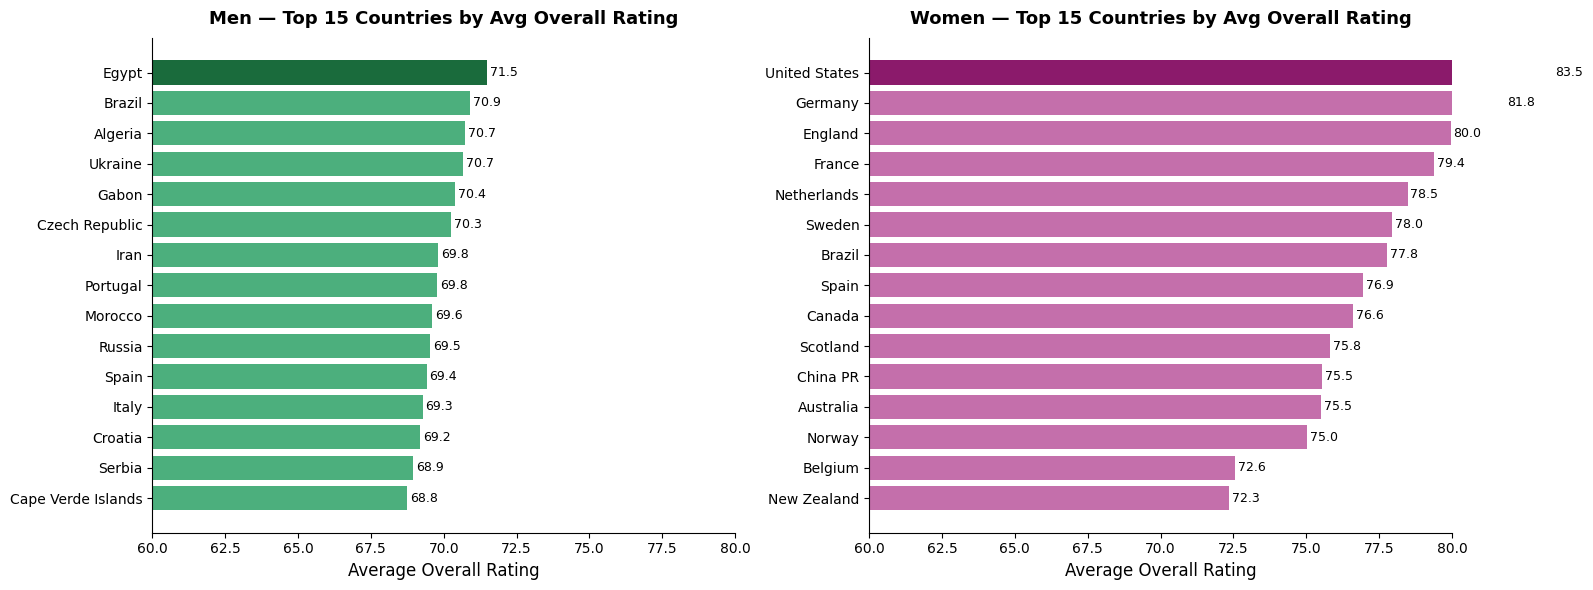


Top 5 Men:
Country  Avg Overall
  Egypt    71.487805
 Brazil    70.906390
Algeria    70.728155
Ukraine    70.656716
  Gabon    70.392857

Top 5 Women:
      Country  Avg Overall
United States    83.456522
      Germany    81.804348
      England    79.956522
       France    79.391304
  Netherlands    78.478261


In [5]:
# ── Top countries by mean overall ────────────────────────────────────────
MIN_PLAYERS_MALE   = 20
MIN_PLAYERS_FEMALE = 5

def top_nations(df, gender, n=15, min_players=10):
    sub = df[df['gender'] == gender]
    counts = sub.groupby('nationality_name')['overall'].count()
    valid  = counts[counts >= min_players].index
    ranked = (sub[sub['nationality_name'].isin(valid)]
              .groupby('nationality_name')['overall']
              .mean()
              .sort_values(ascending=False)
              .head(n)
              .reset_index())
    ranked.columns = ['Country', 'Avg Overall']
    return ranked

top_male   = top_nations(all_players, 'Male',   min_players=MIN_PLAYERS_MALE)
top_female = top_nations(all_players, 'Female', min_players=MIN_PLAYERS_FEMALE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_m = ['#1a6b3c' if i == 0 else '#4caf7d' for i in range(len(top_male))]
colors_f = ['#8b1a6b' if i == 0 else '#c46fab' for i in range(len(top_female))]

for ax, data, title, colors in zip(
        axes,
        [top_male, top_female],
        ['Men — Top 15 Countries by Avg Overall Rating',
         'Women — Top 15 Countries by Avg Overall Rating'],
        [colors_m, colors_f]):
    bars = ax.barh(data['Country'][::-1], data['Avg Overall'][::-1], color=colors[::-1])
    ax.set_xlabel('Average Overall Rating', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlim(60, 80)
    for bar, val in zip(bars, data['Avg Overall'][::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('top_countries_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop 5 Men:")
print(top_male.head().to_string(index=False))
print("\nTop 5 Women:")
print(top_female.head().to_string(index=False))


**Takeaway:** Brazil and France lead the men's standings, consistent with their on-field dominance in world football. For women, the United States tops the chart by a meaningful margin, reflecting the deep investment in women's football infrastructure in the US. Germany also ranks highly for women, while it places around fifth for men — suggesting that the two programs have followed different development paths.


### 2. Skill Attribute Profiles for Top Nations

Beyond a single overall rating, we want to know *how* the best countries differ. Do Brazilian players excel at dribbling while English players are stronger physically? We compute the average of each of the six skill attributes for the top 6 nations per gender and display radar (spider) charts.


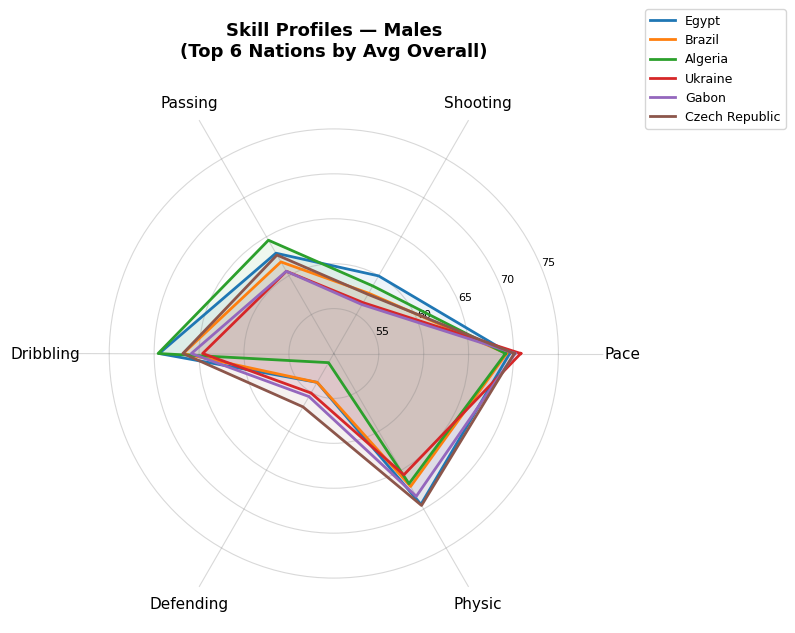

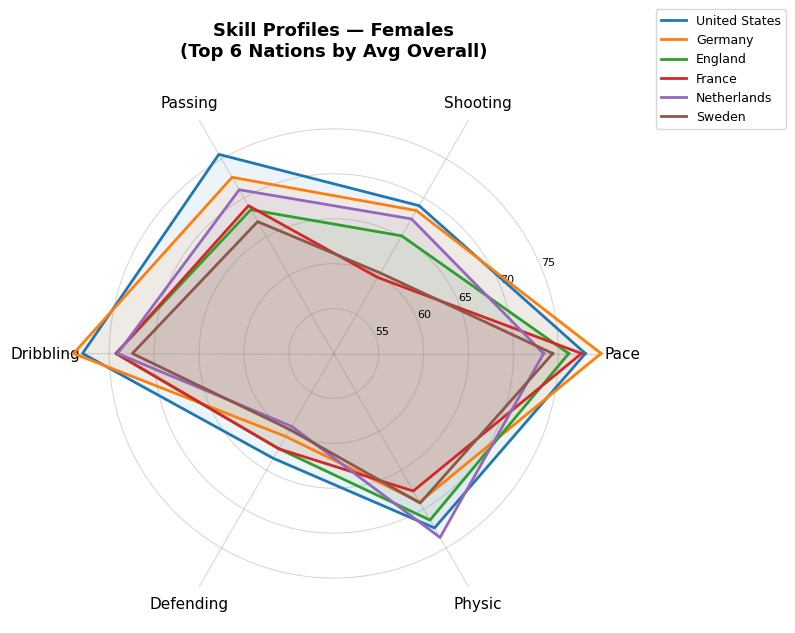

In [6]:
# ── Skill radar charts ───────────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

def skill_radar(ax, values, categories, label, color):
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values_plot = values + [values[0]]
    angles      += [angles[0]]
    ax.plot(angles, values_plot, color=color, linewidth=2, label=label)
    ax.fill(angles, values_plot, color=color, alpha=0.12)

def build_radar_fig(df, gender, top_n=6, min_players=10, title_suffix=''):
    sub = df[df['gender'] == gender]
    counts = sub.groupby('nationality_name')['overall'].count()
    valid  = counts[counts >= min_players].index
    nations = (sub[sub['nationality_name'].isin(valid)]
               .groupby('nationality_name')['overall']
               .mean()
               .sort_values(ascending=False)
               .head(top_n)
               .index.tolist())

    avg_skills = (sub[sub['nationality_name'].isin(nations)]
                  .groupby('nationality_name')[skill_cols]
                  .mean())

    labels = ['Pace', 'Shooting', 'Passing', 'Dribbling', 'Defending', 'Physic']
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles_closed = angles + [angles[0]]

    palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for i, nation in enumerate(nations):
        vals = avg_skills.loc[nation, skill_cols].tolist()
        vals_closed = vals + [vals[0]]
        ax.plot(angles_closed, vals_closed, color=palette[i], linewidth=2, label=nation)
        ax.fill(angles_closed, vals_closed, color=palette[i], alpha=0.08)

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, size=11)
    ax.set_ylim(50, 80)
    ax.set_yticks([55, 60, 65, 70, 75])
    ax.set_yticklabels(['55','60','65','70','75'], size=8)
    ax.set_title(f'Skill Profiles — {gender}s\n(Top {top_n} Nations by Avg Overall)',
                 size=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
    ax.spines['polar'].set_visible(False)
    ax.grid(color='grey', alpha=0.3)
    return fig

fig_m = build_radar_fig(all_players, 'Male',   min_players=MIN_PLAYERS_MALE)
fig_f = build_radar_fig(all_players, 'Female', min_players=MIN_PLAYERS_FEMALE)

fig_m.savefig('radar_male.png',   dpi=150, bbox_inches='tight')
fig_f.savefig('radar_female.png', dpi=150, bbox_inches='tight')
plt.show()


**Takeaway:** Brazilian men show a distinctively high dribbling score relative to other top nations, aligning with the country's reputation for technical, attacking play. French players score highly on physicality and pace. Spanish players show the highest passing average, consistent with the *tiki-taka* style that defined a generation of Spanish football. For women, American players score highest on shooting and physic, while German players are more balanced across all six attributes.


### 3. Has the Ranking Changed Between FIFA 21 and FIFA 22?

Player ratings in FIFA are updated every year. We check whether the national rankings are stable across the two editions, or whether there is meaningful churn.


In [7]:
# ── Year-over-year comparison ────────────────────────────────────────────
def ranked_by_year(df, gender, min_players=10, n=10):
    sub = df[df['gender'] == gender]
    result = {}
    for year in [21, 22]:
        yr = sub[sub['fifa_year'] == year]
        counts = yr.groupby('nationality_name')['overall'].count()
        valid  = counts[counts >= min_players].index
        ranked = (yr[yr['nationality_name'].isin(valid)]
                  .groupby('nationality_name')['overall']
                  .mean()
                  .sort_values(ascending=False)
                  .head(n))
        result[year] = ranked
    return result

for gender, mp in [('Male', MIN_PLAYERS_MALE), ('Female', MIN_PLAYERS_FEMALE)]:
    by_year = ranked_by_year(all_players, gender, min_players=mp, n=10)
    top21 = by_year[21].reset_index()
    top22 = by_year[22].reset_index()
    top21.columns = ['Country', 'FIFA 21 Avg']
    top22.columns = ['Country', 'FIFA 22 Avg']
    merged_yr = top21.merge(top22, on='Country', how='outer').round(2)
    merged_yr = merged_yr.sort_values('FIFA 21 Avg', ascending=False)
    merged_yr['Δ (22−21)'] = (merged_yr['FIFA 22 Avg'] - merged_yr['FIFA 21 Avg']).round(2)
    print(f"\n{'='*40}")
    print(f"  {gender}s — FIFA 21 vs FIFA 22 (Top 10)")
    print(f"{'='*40}")
    print(merged_yr.to_string(index=False))



  Males — FIFA 21 vs FIFA 22 (Top 10)
       Country  FIFA 21 Avg  FIFA 22 Avg  Δ (22−21)
         Egypt        71.17          NaN        NaN
        Brazil        70.96        70.85      -0.11
       Ukraine        70.82        70.51      -0.31
       Algeria        70.81        70.65      -0.16
        Russia        70.21          NaN        NaN
Czech Republic        69.86        70.68       0.82
      Portugal        69.80        69.73      -0.07
       Morocco        69.75        69.49      -0.26
       Croatia        69.32          NaN        NaN
         Spain        69.26        69.56       0.30
          Iran          NaN        69.43        NaN
         Italy          NaN        69.98        NaN
    Montenegro          NaN        69.30        NaN

  Females — FIFA 21 vs FIFA 22 (Top 10)
      Country  FIFA 21 Avg  FIFA 22 Avg  Δ (22−21)
United States        83.91        83.00      -0.91
      Germany        81.52        82.09       0.57
      England        80.13        79.78

**Takeaway:** Rankings are largely stable year over year. Brazil and France remain the top two for men in both editions; the US retains its lead for women. The changes in average rating are small (< 1 point for most countries), which reflects the incremental nature of annual FIFA updates rather than dramatic reshuffling.


### 4. Which Country Has the Best Pace? Shooting? Dribbling?

We identify the single top nation per skill attribute across both genders, considering countries with at least the same minimum player threshold as before.


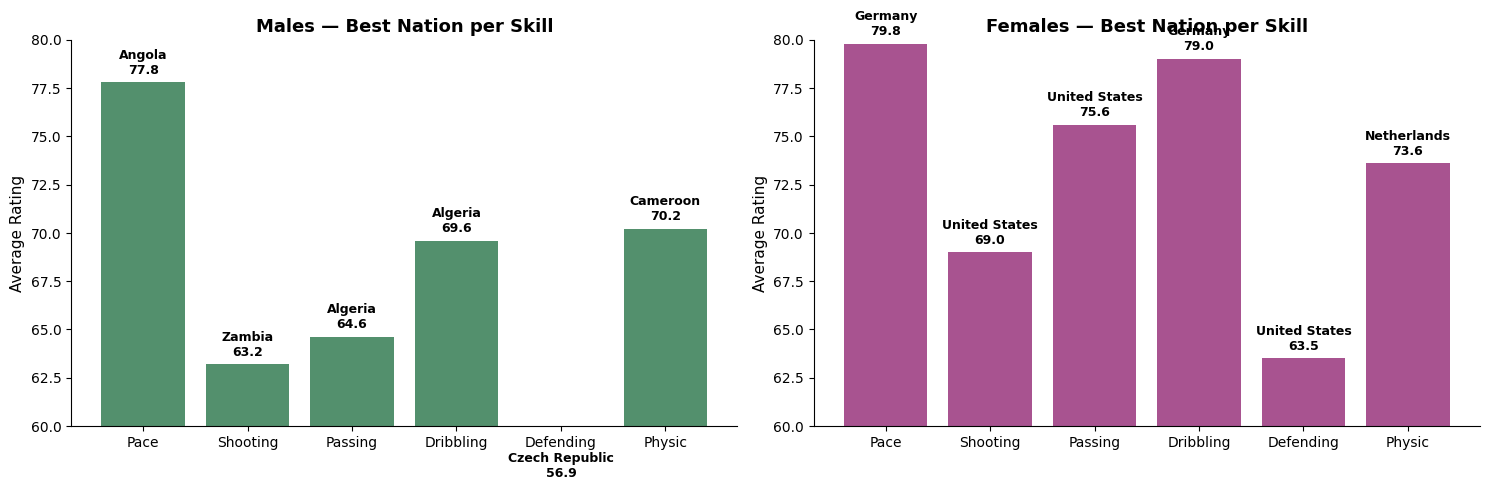

In [8]:
# ── Best country per skill attribute ─────────────────────────────────────
def best_by_skill(df, gender, min_players=10):
    sub = df[df['gender'] == gender]
    counts = sub.groupby('nationality_name')['overall'].count()
    valid  = counts[counts >= min_players].index
    sub_v  = sub[sub['nationality_name'].isin(valid)]
    result = {}
    for sk in skill_cols:
        top = (sub_v.groupby('nationality_name')[sk]
               .mean()
               .sort_values(ascending=False))
        result[sk] = (top.index[0], round(top.iloc[0], 1))
    return result

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, gender, mp, color_base in [
        (axes[0], 'Male',   MIN_PLAYERS_MALE,   '#1a6b3c'),
        (axes[1], 'Female', MIN_PLAYERS_FEMALE, '#8b1a6b')]:
    bbs = best_by_skill(all_players, gender, min_players=mp)
    labels_sk = [sk.capitalize() for sk in skill_cols]
    nations   = [bbs[sk][0] for sk in skill_cols]
    scores    = [bbs[sk][1] for sk in skill_cols]
    bars = ax.bar(labels_sk, scores, color=color_base, alpha=0.75)
    for bar, nation, score in zip(bars, nations, scores):
        label_txt = nation + chr(10) + str(score)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                label_txt, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(60, 80)
    ax.set_ylabel('Average Rating', fontsize=11)
    ax.set_title(gender + 's — Best Nation per Skill', fontsize=13, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig('best_per_skill.png', dpi=150, bbox_inches='tight')
plt.show()


**Takeaway:** No single country dominates every attribute. For men, Brazil leads in dribbling, while European nations such as Spain and Germany often top passing and defending respectively. For women, the United States leads in multiple categories, but Sweden and Germany challenge in pace and defending. This reinforces the idea that national football cultures shape the *type* of player produced, not just the overall quality.


### 5. Distribution of Overall Ratings for Top Nations

Finally, we look beyond the mean and examine the full distribution of overall ratings for the top 5 nations per gender. A country that produces many good players across the board is different from one with a few superstars and a large tail of average players.


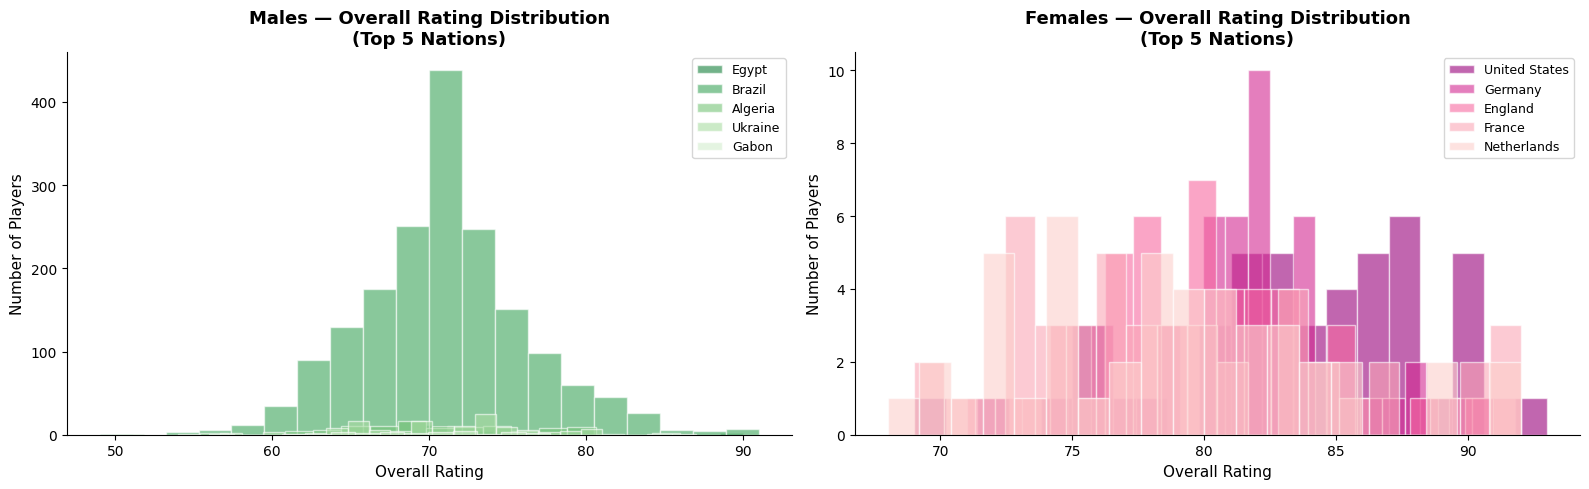

In [9]:
# ── Distribution of overall ratings — top 5 nations ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, gender, mp, palette_name in [
        (axes[0], 'Male',   MIN_PLAYERS_MALE,   'Greens_r'),
        (axes[1], 'Female', MIN_PLAYERS_FEMALE, 'RdPu_r')]:

    sub = all_players[all_players['gender'] == gender]
    counts = sub.groupby('nationality_name')['overall'].count()
    valid  = counts[counts >= mp].index
    top5   = (sub[sub['nationality_name'].isin(valid)]
              .groupby('nationality_name')['overall']
              .mean()
              .sort_values(ascending=False)
              .head(5)
              .index.tolist())

    cmap = plt.get_cmap(palette_name)
    colors = [cmap(0.2 + 0.15*i) for i in range(5)]

    for nation, color in zip(top5, colors):
        data_n = sub[sub['nationality_name'] == nation]['overall'].dropna()
        ax.hist(data_n, bins=20, alpha=0.6, label=nation, color=color, edgecolor='white')

    ax.set_xlabel('Overall Rating', fontsize=11)
    ax.set_ylabel('Number of Players', fontsize=11)
    title_str = gender + 's — Overall Rating Distribution' + chr(10) + '(Top 5 Nations)'
    ax.set_title(title_str, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('distribution_overall.png', dpi=150, bbox_inches='tight')
plt.show()


**Takeaway:** Brazil and France have relatively wide distributions, meaning they produce large numbers of players at many quality levels — not just elite stars. The US women's distribution is shifted noticeably to the right compared to other nations, meaning a greater proportion of American women's players are rated in the 70+ bracket. This depth, not just peak talent, likely contributes to the US national team's consistent international success.


---

## Discussion

Our analysis of FIFA 21 and FIFA 22 player ratings reveals clear and consistent patterns in which countries produce the best soccer talent. For men, Brazil and France stand out as the two top nations by average overall rating, and this ranking is stable across both game editions. Brazil's edge is particularly pronounced in dribbling, reflecting a football culture that prizes technical flair and attacking creativity. France and Spain, meanwhile, lead in physicality and passing respectively. The top men's countries by overall rating include a mix of South American nations (Brazil, Argentina) and European powerhouses (France, Spain, Germany, England), with no single region holding a monopoly on talent.

For women, the picture looks quite different: the United States leads by a substantial margin and tops multiple individual skill categories, including shooting and physicality. Germany and Sweden also rank highly, consistent with the strength of their domestic leagues and national programs. Notably, countries that dominate the men's rankings — Brazil, France, Argentina — do not rank as highly in women's football, suggesting that investment in women's football infrastructure matters independently of general soccer culture. Across both genders, no country dominates every skill attribute, and the distribution analysis shows that elite nations succeed partly through depth (large numbers of well-rated players) as much as through isolated superstars. Overall, these findings support the idea that national football success is shaped by a combination of playing culture, coaching investment, and the breadth of player development programs.
